In [1]:
import json
from typing import List, Dict
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from transformers import DebertaV2Tokenizer

from scipy.stats import pearsonr
from tqdm import tqdm
import math
import re
import requests

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))

    
def load_jsonl(filepath: str) -> List[Dict]:
    with open(filepath, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

def load_jsonl_url(url: str) -> List[Dict]:
    resp = requests.get(url)
    resp.raise_for_status()
    return [json.loads(line) for line in resp.text.splitlines()]

torch: 2.9.1+cu126
cuda available: True
device: NVIDIA GeForce RTX 4070


In [2]:
#task config
subtask = "subtask_1"#don't change
task = "task1"#don't change
lang = "eng" #chang the language you want to test
domain = "laptop" #change what domain you want to test

train_url = f"https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/{subtask}/{lang}/{lang}_{domain}_train_alltasks.jsonl"
predict_url = f"https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/{subtask}/{lang}/{lang}_{domain}_dev_{task}.jsonl"

#model config
model_name = "xlm-roberta-base" # chage your transformer model
lr = 2e-5 #learning rate
epochs = 20

train_raw = load_jsonl_url(train_url)
predict_raw = load_jsonl_url(predict_url)


#==== step 1 load the data ====
# you can change the env for your task.
# train data should have the VA labels, predit data without VA labels

def jsonl_to_df(data):
    if 'Quadruplet' in data[0]:
        df = pd.json_normalize(data, 'Quadruplet', ['ID', 'Text'])
        df[['Valence', 'Arousal']] = df['VA'].str.split('#', expand=True).astype(float)
        df = df.drop(columns=['VA', 'Category', 'Opinion'])  # drop unnecessary columns
        df = df.drop_duplicates(subset=['ID', 'Aspect'], keep='first')  # remove duplicate ID+Aspect

    elif 'Triplet' in data[0]:
        df = pd.json_normalize(data, 'Triplet', ['ID', 'Text'])
        df[['Valence', 'Arousal']] = df['VA'].str.split('#', expand=True).astype(float)
        df = df.drop(columns=['VA', 'Opinion'])  # drop unnecessary columns
        df = df.drop_duplicates(subset=['ID', 'Aspect'], keep='first')  # remove duplicate ID+Aspect

    elif 'Aspect_VA' in data[0]:
        df = pd.json_normalize(data, 'Aspect_VA', ['ID', 'Text'])
        df = df.rename(columns={df.columns[0]: "Aspect"})  # rename to Aspect
        df[['Valence', 'Arousal']] = df['VA'].str.split('#', expand=True).astype(float)
        df = df.drop_duplicates(subset=['ID', 'Aspect'], keep='first')  # remove duplicate ID+Aspect

    elif 'Aspect' in data[0]:
        df = pd.json_normalize(data, 'Aspect', ['ID', 'Text'])
        df = df.rename(columns={df.columns[0]: "Aspect"})  # rename to Aspect
        df['Valence'] = 0  # default value
        df['Arousal'] = 0  # default value

    else:
        raise ValueError("Invalid format: must include 'Quadruplet' or 'Triplet' or 'Aspect'")

    return df

train_df = jsonl_to_df(train_raw)
predict_df = jsonl_to_df(predict_raw)

# split 10% for dev
train_df, dev_df = train_test_split(train_df, test_size=0.1, random_state=42)


from IPython.display import display, Markdown

display(Markdown(f"### {subtask}_{lang}_{domain} train_df"))
display(train_df.head())

display(Markdown(f"### {subtask}_{lang}_{domain} dev_df"))
display(dev_df.head())

display(Markdown(f"### {subtask}_{lang}_{domain} predict_df"))
display(predict_df.head())




### subtask_1_eng_laptop train_df

,Aspect,ID,Text,Valence,Arousal
251,computer,laptop_quad_dev_190,"if i had it to do over , i would not purchase ...",3.10,6.30
4516,unit,laptop_quad_train_2141,after charging the unit for 2 hours i discover...,4.75,5.25
335,NULL,laptop_quad_dev_253,"freezes with red lines across it , froze five ...",2.00,7.67
3286,device,laptop_quad_train_1230,a wonderful device with extremely clear display .,8.00,7.83
753,screen,laptop_quad_test_236,the screen does look good .,6.62,6.62


### subtask_1_eng_laptop dev_df

,Aspect,ID,Text,Valence,Arousal
3628,NULL,laptop_quad_train_1485,but it lost the coil whine roulette - - badly .,3.12,6.12
3096,key board,laptop_quad_train_1095,the key board is one of the best i ' ve ever t...,7.67,7.50
4814,sleep time,laptop_quad_train_2357,"- boot time , sleep time and wake time are cra...",7.50,7.50
5443,track pad,laptop_quad_train_2729,please note that the track pad is way better t...,7.12,7.00
197,retina screen,laptop_quad_dev_147,the retina screen is amazing .,8.12,8.25


### subtask_1_eng_laptop predict_df

,Aspect,ID,Text,Valence,Arousal
0,touchscreen,lap26_aspect_va_dev_1,The touchscreen works very well,0,0
1,HP,lap26_aspect_va_dev_2,I am so disappointed in HP,0,0
2,keyboard,lap26_aspect_va_dev_3,The keyboard is big enough to use for real typing,0,0
3,screen size,lap26_aspect_va_dev_4,I like the screen size,0,0
4,Lenovo,lap26_aspect_va_dev_5,Lenovo is my favorite brand of computer,0,0


In [3]:

#==== Dataset ====
class VADataset(Dataset):
    '''
    A PyTorch Dataset for Valence–Arousal regression.

    - Combines aspect and text into a single input (e.g., "keyboard: The keyboard is good").
    - Tokenizes the input using a HuggingFace tokenizer.
    - Returns:
        * input_ids: token IDs, shape [max_len]
        * attention_mask: mask, shape [max_len]
        * labels: [Valence, Arousal], shape [2], float tensor

    Args:
        dataframe (pd.DataFrame): must contain "Text", "Aspect", "Valence", "Arousal".
        tokenizer: HuggingFace tokenizer.
        max_len (int): max sequence length.
    '''
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.sentences = dataframe["Text"].tolist()
        self.aspects = dataframe["Aspect"].tolist()
        self.labels = dataframe[["Valence", "Arousal"]].values.astype(float)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        text = f"{self.aspects[idx]}: {self.sentences[idx]}"
        encoded = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float)
        }

model_name = "xlm-roberta-base" 

tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset = VADataset(train_df, tokenizer, max_len=256)
dev_dataset  = VADataset(dev_df,  tokenizer, max_len=256)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
dev_loader   = DataLoader(dev_dataset,  batch_size=16, shuffle=False)

In [4]:

#====step 3 build your model ====
class TransformerVARegressor(nn.Module):
    '''
    A BERT-based regressor for predicting Valence and Arousal scores.

    - Uses a pretrained BERT backbone to encode text.
    - Takes the [CLS] token representation as sentence-level embedding.
    - Adds a dropout layer and a linear head to output 2 values: [Valence, Arousal].
    - Includes helper methods for one training epoch and one evaluation epoch.

    Args:
        model_name (str): HuggingFace model name, default "bert-base-multilingual-cased".
        dropout (float): Dropout rate before the regression head.

    Methods:
        train_epoch(dataloader, optimizer, loss_fn, device):
            Train the model for one epoch.
            Returns average training loss.

        eval_epoch(dataloader, loss_fn, device):
            Evaluate the model for one epoch (no gradient).
            Returns average validation loss.
    '''
    def __init__(self, model_name=model_name, dropout=0.1):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.reg_head = nn.Linear(self.backbone.config.hidden_size, 2)  # Valence + Arousal

    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0]  # [CLS] token
        x = self.dropout(cls_output)
        return self.reg_head(x)


    def train_epoch(self, dataloader, optimizer, loss_fn, device):
        self.train()
        total_loss = 0
        for batch in tqdm(dataloader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = self(input_ids, attention_mask)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        return total_loss / len(dataloader)

    def eval_epoch(self, dataloader, loss_fn, device):
        self.eval()
        total_loss = 0
        with torch.no_grad():
            for batch in dataloader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = self(input_ids, attention_mask)
                loss = loss_fn(outputs, labels)
                total_loss += loss.item()
        return total_loss / len(dataloader)
# lr = 2e-5
# max_epochs = 40     # allow more epochs
# patience = 3        # stop if no improvement for 3 checks
# min_delta = 1e-4    # minimum change to qualify as improvement
# # Training bert on your data
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = TransformerVARegressor().to(device)
# print(next(model.parameters()).dtype)

# lr = locals().get("lr", 2e-5)
# epochs = locals().get("epochs", 20)

# optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
# loss_fn = nn.MSELoss()

# best_val = float("inf")
# best_epoch = -1
# best_state = None
# no_improve = 0

# #Added Best model early stopping
# for epoch in range(epochs):
#     train_loss = model.train_epoch(train_loader, optimizer, loss_fn, device)
#     val_loss = model.eval_epoch(dev_loader, loss_fn, device)
#     print(f"model:{model_name} Epoch:{epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}")
#     if val_loss < best_val - min_delta:
#         best_val = val_loss
#         best_epoch = epoch + 1
#         best_state = model.state_dict()
#         no_improve = 0
#         print(f" New best val: {best_val:.4f} (epoch {best_epoch})")
#     else:
#         no_improve += 1
#         print(f" No improvement ({no_improve}/{patience})")

#     if no_improve >= patience:
#         print(f"Early stopping at epoch {epoch+1}")
#         break
# model.load_state_dict(best_state)
# print(f"Model restored to best epoch: {best_epoch} with best val {best_val:.4f}")
def train_and_eval_once(model_name, lr, dropout,
                        train_loader, dev_loader,
                        max_epochs=30, patience=3, min_delta=1e-4):
    """
    Train a fresh model with given hyperparams and return:
      - dev RMSE_VA
      - full metric dict
      - train loss history
      - val loss history
    """

    model = TransformerVARegressor(model_name=model_name, dropout=dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_epoch = -1
    best_state = None
    no_improve = 0

    train_history = []
    val_history   = []

    for epoch in range(max_epochs):
        train_loss = model.train_epoch(train_loader, optimizer, loss_fn, device)
        val_loss   = model.eval_epoch(dev_loader,  loss_fn, device)

        train_history.append(train_loss)
        val_history.append(val_loss)

        print(f"model:{model_name} Epoch:{epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}")

        if val_loss < best_val - min_delta:
            best_val = val_loss
            best_epoch = epoch + 1
            best_state = model.state_dict()
            no_improve = 0
            print(f" New best val: {best_val:.4f} (epoch {best_epoch})")
        else:
            no_improve += 1
            print(f" No improvement ({no_improve}/{patience})")
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # restore best model
    model.load_state_dict(best_state)
    print(f"Model restored to best epoch: {best_epoch} with best val {best_val:.4f}")

    # compute dev metrics
    pred_v, pred_a, gold_v, gold_a = get_prd(model, dev_loader, type="dev")
    scores = evaluate_predictions_task1(pred_a, pred_v, gold_a, gold_v)
    rmse_va = scores["RMSE_VA"]
    print(f"dev_eval: {scores}")

    return rmse_va, scores, train_history, val_history, model


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#==== step 4 use dev data to check your model's performance ====
def get_prd(model,dataloder, type ="dev"):
    if type == "dev":
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in dataloder:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].cpu().numpy()
                outputs = model(input_ids, attention_mask).cpu().numpy()
                all_preds.append(outputs)
                all_labels.append(labels)
        preds = np.vstack(all_preds)
        lables = np.vstack(all_labels)

        pred_v = preds[:,0]
        pred_a = preds[:,1]

        gold_v = lables[:,0]
        gold_a = lables[:,1]

        return pred_v, pred_a, gold_v, gold_a

    elif type == "pred":
        all_preds = []
        with torch.no_grad():
            for batch in dataloder:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids, attention_mask).cpu().numpy()
                all_preds.append(outputs)
        preds = np.vstack(all_preds)

        pred_v = preds[:, 0]
        pred_a = preds[:, 1]

        return pred_v, pred_a

# def rmse_pairwise(pred_a, pred_v, gold_a, gold_v):
#     pcc_v = pearsonr(pred_v,gold_v)[0]
#     pcc_a = pearsonr(pred_a,gold_a)[0]
#     total_sq_error = sum((pv - gv)**2 + (pa - ga)**2 for gv,pv,ga,pa in zip(gold_v, pred_v, gold_a, pred_a))
#     rmse_va = math.sqrt(total_sq_error / len(gold_v))

#     return {
#         'PCC_V': pcc_v,
#         'PCC_A': pcc_a,
#         'RMSE_VA': rmse_va,
#     }

# def rmse_concat(pred_a, pred_v, gold_a, gold_v):
#     pcc_v = pearsonr(pred_v,gold_v)[0]
#     pcc_a = pearsonr(pred_a,gold_a)[0]

#     gold_va = list(gold_v) + list(gold_a)
#     pred_va = list(pred_v) + list(pred_a)
#     total_sq_error = [(a - b)**2 for a,b in zip(gold_va, pred_va)]
#     rmse_va = math.sqrt(sum(total_sq_error) / len(gold_v))
#     return {
#         'PCC_V': pcc_v,
#         'PCC_A': pcc_a,
#         'RMSE_VA': rmse_va,
#     }

def evaluate_predictions_task1(pred_a, pred_v, gold_a, gold_v, is_norm = False):
    if not (all(1 <= x <= 9 for x in pred_v) and all(1 <= x <= 9 for x in pred_a)):
        print(f"Warning: Some predicted values are out of the numerical range.")
    pcc_v = pearsonr(pred_v,gold_v)[0]
    pcc_a = pearsonr(pred_a,gold_a)[0]

    gold_va = list(gold_v) + list(gold_a)
    pred_va = list(pred_v) + list(pred_a)
    def rmse_norm(gold_va, pred_va, is_normalization = True):
        result = [(a - b)**2 for a, b in zip(gold_va, pred_va)]
        if is_normalization:
            return math.sqrt(sum(result)/len(gold_v))/math.sqrt(128)
        return math.sqrt(sum(result)/len(gold_v))
    rmse_va = rmse_norm(gold_va, pred_va, is_norm)
    return {
        'PCC_V': pcc_v,
        'PCC_A': pcc_a,
        'RMSE_VA': rmse_va,
    }
rmse, scores, train_hist, val_hist, model = train_and_eval_once(
    model_name="xlm-roberta-base",
    lr=2e-5,
    dropout=0.1,
    train_loader=train_loader,
    dev_loader=dev_loader
)
from skopt import gp_minimize
from skopt.space import Real

def objective(params):
    lr, dropout = params
    print(f"\n=== Trying lr={lr:.2e}, dropout={dropout:.3f} ===")
    rmse_va, scores, train_hist, val_hist, _ = train_and_eval_once(
        model_name="xlm-roberta-base",
        lr=lr,
        dropout=dropout,
        train_loader=train_loader,
        dev_loader=dev_loader,
        max_epochs=30,
        patience=3,
        min_delta=1e-4
    )
    bayes_trials.append((lr, dropout, rmse_va))
    return rmse_va



space = [
    Real(1e-5, 5e-5, prior="log-uniform", name="lr"),
    Real(0.0, 0.3,   prior="uniform",     name="dropout"),
]
bayes_trials = []  # (lr, dropout, rmse)

res = gp_minimize(
    objective,
    space,
    n_calls=8,           
    n_initial_points=3,
    random_state=42
)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

bayes_df = pd.DataFrame(bayes_trials, columns=["lr", "dropout", "rmse_va"])
print(bayes_df)

print("\nBest hyperparams from Bayesian optimization:")
best_lr, best_dropout = res.x
print("  lr     =", best_lr)
print("  dropout=", best_dropout)
print("  best RMSE_VA =", res.fun)

pred_v, pred_a, gold_v, gold_a = get_prd(model, dev_loader,type="dev")
eval_score = evaluate_predictions_task1(pred_a, pred_v, gold_a, gold_v)




100%|████████████████████████████████████████████████████████████████████████████████| 279/279 [01:02<00:00,  4.48it/s]


model:xlm-roberta-base Epoch:1: train=4.9437, val=2.2657
 New best val: 2.2657 (epoch 1)


100%|████████████████████████████████████████████████████████████████████████████████| 279/279 [01:01<00:00,  4.54it/s]


model:xlm-roberta-base Epoch:2: train=1.7376, val=1.1823
 New best val: 1.1823 (epoch 2)


100%|████████████████████████████████████████████████████████████████████████████████| 279/279 [01:02<00:00,  4.47it/s]


...

model:xlm-roberta-base Epoch:10: train=0.3436, val=0.8466
 No improvement (1/3)


100%|████████████████████████████████████████████████████████████████████████████████| 279/279 [01:01<00:00,  4.51it/s]


model:xlm-roberta-base Epoch:11: train=0.3047, val=0.8096
 No improvement (2/3)


100%|████████████████████████████████████████████████████████████████████████████████| 279/279 [01:02<00:00,  4.46it/s]


model:xlm-roberta-base Epoch:12: train=0.2718, val=0.9018
 No improvement (3/3)
Early stopping at epoch 12
Model restored to best epoch: 9 with best val 0.7069
dev_eval: {'PCC_V': np.float32(0.8666945), 'PCC_A': np.float32(0.7104857), 'RMSE_VA': 1.3429897730559368}
         lr   dropout   rmse_va
0  0.000036  0.055030  1.276886
1  0.000035  0.179055  1.525754
2  0.000020  0.029992  1.254181
3  0.000050  0.000000  1.415650
4  0.000012  0.047124  1.470986
5  0.000020  0.029992  1.334580
6  0.000035  0.052996  1.369554
7  0.000032  0.057132  1.342990

Best hyperparams from Bayesian optimization:
  lr     = 2.049385792919746e-05
  dropout= 0.02999247474540087
  best RMSE_VA = 1.2541805454555017


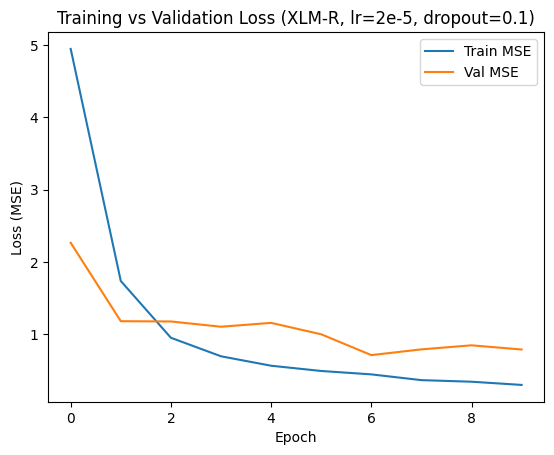

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_hist, label="Train MSE")
plt.plot(val_hist,   label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training vs Validation Loss (XLM-R, lr=2e-5, dropout=0.1)")
plt.legend()
plt.show()


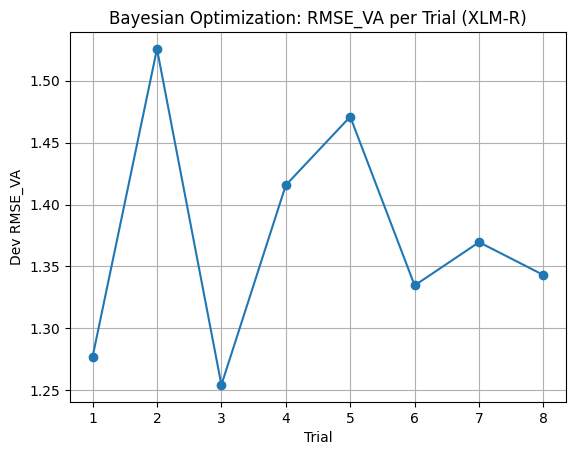

In [7]:
plt.figure()
plt.plot(bayes_df.index + 1, bayes_df["rmse_va"], marker="o")
plt.xlabel("Trial")
plt.ylabel("Dev RMSE_VA")
plt.title("Bayesian Optimization: RMSE_VA per Trial (XLM-R)")
plt.grid(True)
plt.show()


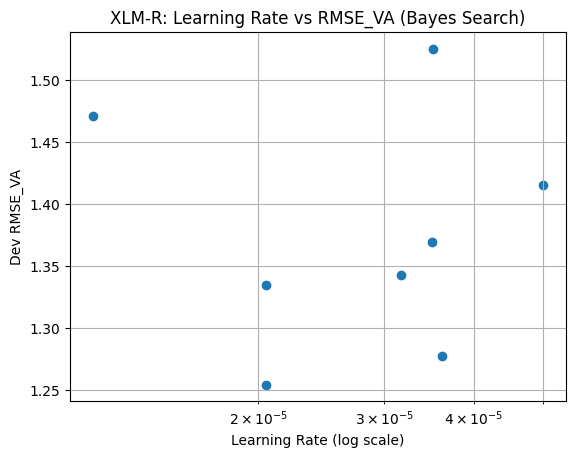

In [8]:
plt.figure()
plt.scatter(bayes_df["lr"], bayes_df["rmse_va"])
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Dev RMSE_VA")
plt.title("XLM-R: Learning Rate vs RMSE_VA (Bayes Search)")
plt.grid(True, which="both")
plt.show()


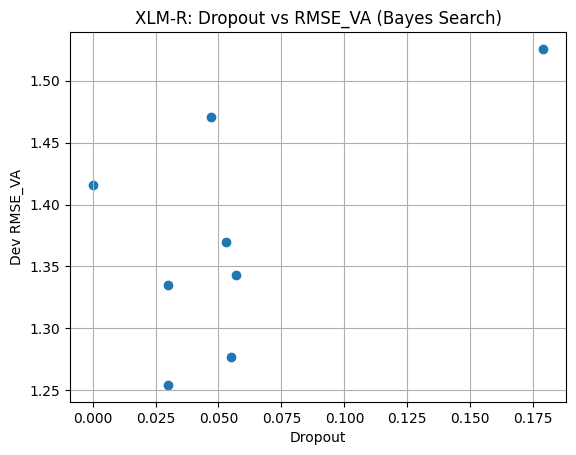

In [9]:
plt.figure()
plt.scatter(bayes_df["dropout"], bayes_df["rmse_va"])
plt.xlabel("Dropout")
plt.ylabel("Dev RMSE_VA")
plt.title("XLM-R: Dropout vs RMSE_VA (Bayes Search)")
plt.grid(True)
plt.show()


In [10]:

#==== step 5 save & submit your predict results ====
def extract_num(s):
    m = re.search(r"(\d+)$", str(s))
    return int(m.group(1)) if m else -1

def df_to_jsonl(df, out_path):
    df_sorted = df.sort_values(by="ID", key=lambda x: x.map(extract_num))
    grouped = df_sorted.groupby("ID", sort=False)

    with open(out_path, "w", encoding="utf-8") as f:
        for gid, gdf in grouped:
            record = {
                "ID": gid,
                "Aspect_VA": []
            }
            for _, row in gdf.iterrows():
                record["Aspect_VA"].append({
                    "Aspect": row["Aspect"],
                    "VA": f"{row['Valence']:.2f}#{row['Arousal']:.2f}"
                }) 
            f.write(json.dumps(record, ensure_ascii=False) + "\n")

pred_dataset = VADataset(predict_df, tokenizer)
pred_loader = DataLoader(pred_dataset, batch_size=64, shuffle=True)
pred_v, pred_a, = get_prd(model, pred_loader,type="pred")

predict_df["Valence"] = pred_v
predict_df["Arousal"] = pred_a

df_to_jsonl(predict_df, f"pred_{lang}_{domain}.jsonl")



In [11]:


# create zip and provide local download link (works outside Colab)
import os, shutil, zipfile
from IPython.display import FileLink

subtask = "XLM-RoBERTaV2 Epoch 15"
os.makedirs(subtask, exist_ok=True)

# move or write your files into `subtask` (adapt this list)
for fname in ["pred_en_domain.jsonl"]:
    if os.path.exists(fname):
        shutil.move(fname, os.path.join(subtask, fname))

zip_path = f"{subtask}.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(subtask):
        for file in files:
            path = os.path.join(root, file)
            zf.write(path, os.path.relpath(path, start=os.path.dirname(subtask)))

print("Saved:", zip_path)
# show a download link in Jupyter
FileLink(zip_path)

Saved: XLM-RoBERTaV2 Epoch 15.zip


D:\Yuri\CU BOULDER\Masters\NLP\Project SemEVal\NLP_SEM_EVAL\XLM-RoBERTaV2 Epoch 15.zip

SUMMARY: 

Run V3: 

Best val loss (MSE): 0.7196 (epoch 11)
dev_eval:
- PCC_V ≈ 0.8848
- PCC_A ≈ 0.7308
- RMSE_VA ≈ 1.2516

Run V4:
Best val loss (MSE): 0.8070 (epoch 9)
dev_eval:
- PCC_V ≈ 0.8844
- PCC_A ≈ 0.7142
- RMSE_VA ≈ 1.2974

Changed to 20 epochs, with early stopping rounds. Due to performance increase for higher learning rate, I should increase to learning rate 3e-5





Update:
V5
Best val MSE: 0.7052 (epoch 7)

dev_eval:
- PCC_V ≈ 0.8773
- PCC_A ≈ 0.7243
- RMSE_VA ≈ 1.2517


we see that there is not much improvement, so we should pick 2e-5 as our learning rate params.

We should change model to 
microsoft/mdeberta-v3-base


best val loss (MSE): 0.6921 at epoch 6

microsoft/mdeberta-v3-base dev_eval:
  PCC_V   ≈ 0.913
  PCC_A   ≈ 0.721
  RMSE_VA ≈ 1.2510

  



In [12]:
V7: Notes: Use Baysian


SyntaxError: invalid syntax (24291388.py, line 1)